# Logistic regression

## Importación de librerías y paquetes y definición de constantes

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Imputador
from sklearn.impute import KNNImputer
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# from tqdm import tqdm
import warnings


In [103]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Recopilación de datos

In [104]:
df = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Análisis descriptivo 

In [105]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [106]:
df.shape

(768, 9)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [108]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [109]:
df.duplicated().sum()

np.int64(0)

### No hay duplicados pero nos aseguramos de borrarlos

In [110]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [111]:
df.duplicated().sum()

np.int64(0)

### Valores nulos o faltantes:

In [112]:
df.isnull().sum().sort_values(ascending=False) / len(df)

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

#### No hay valores nulos

### Limpieza de datos: Eliminar información irrelevante

In [113]:
corr_outcome = df.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)
corr_outcome

Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

#### No eliminamos ninguna variable porque pueden tener cierta influencia en la variable objetivo

In [114]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## Análisis de variables:

### Variables univariante: variables númericas

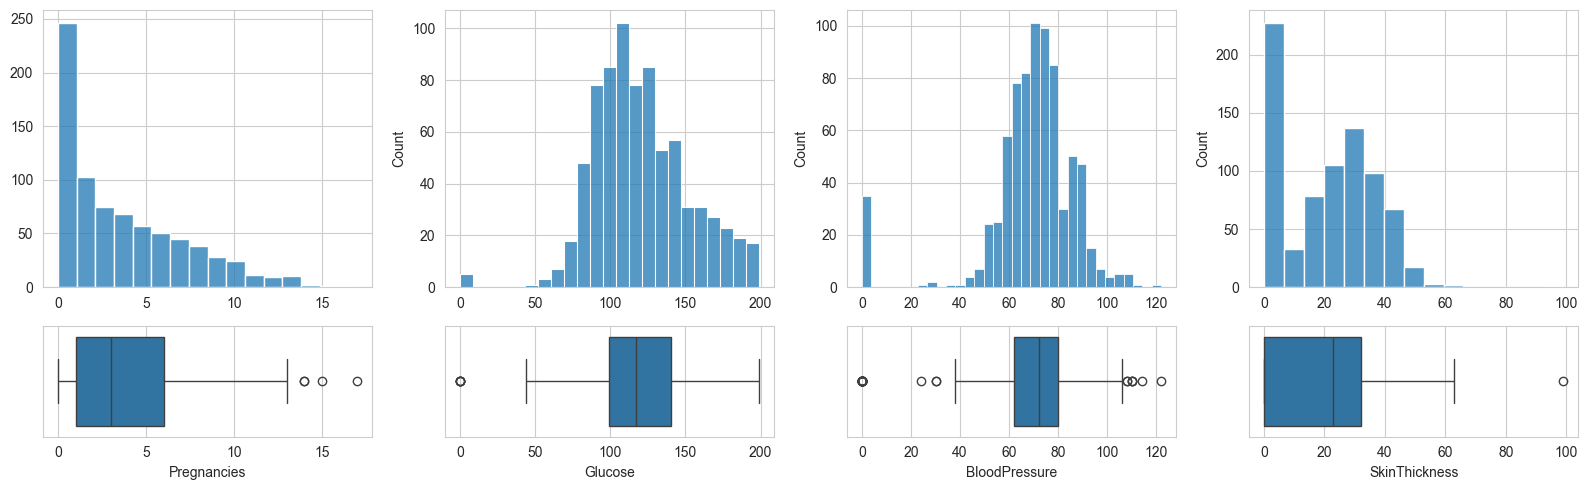

In [115]:
fig, axis = plt.subplots(2, 4, figsize=(16, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="Pregnancies").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="Pregnancies")
sns.histplot(ax=axis[0, 1], data=df, x="Glucose").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="Glucose")
sns.histplot(ax=axis[0, 2], data=df, x="BloodPressure").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="BloodPressure")
sns.histplot(ax=axis[0, 3], data=df, x="SkinThickness").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="SkinThickness")

plt.tight_layout()
plt.show()

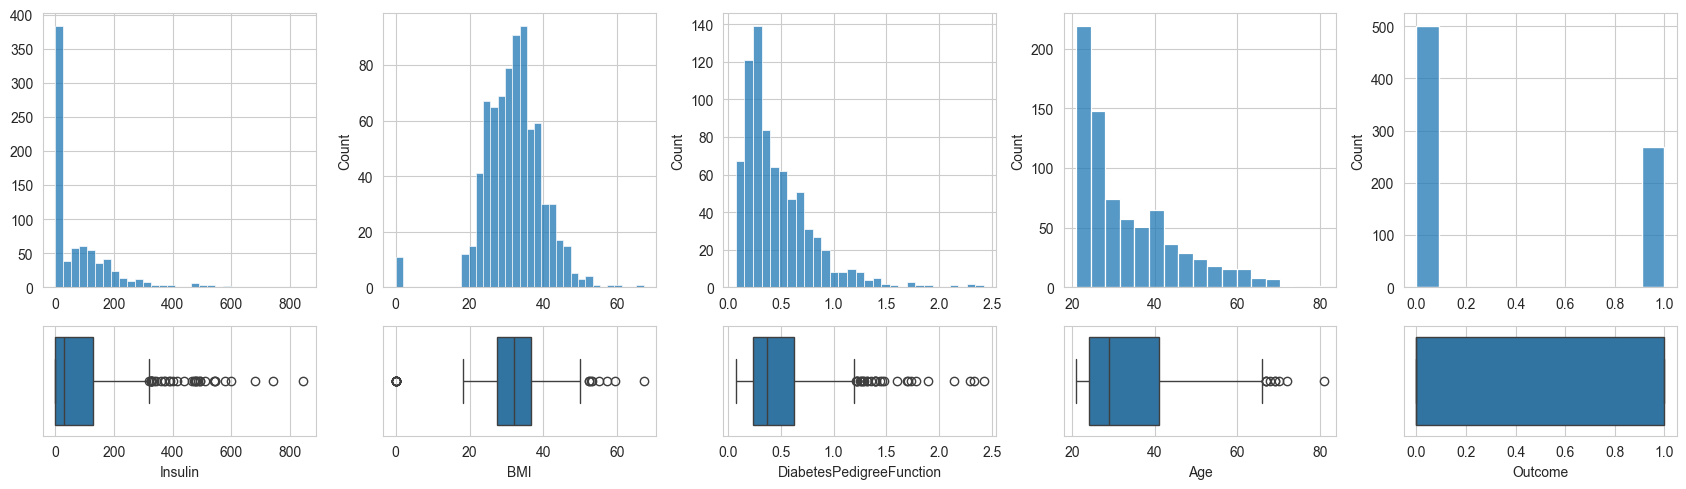

In [116]:
fig, axis = plt.subplots(2, 5, figsize=(17, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="Insulin").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="Insulin")
sns.histplot(ax=axis[0, 1], data=df, x="BMI").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="BMI")
sns.histplot(ax=axis[0, 2], data=df, x="DiabetesPedigreeFunction").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="DiabetesPedigreeFunction")
sns.histplot(ax=axis[0, 3], data=df, x="Age").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="Age")
sns.histplot(ax=axis[0, 4], data=df, x="Outcome").set(xlabel=None)
sns.boxplot(ax=axis[1, 4], data=df, x="Outcome")
plt.tight_layout()
plt.show()

> #### Observaciones:
>
> - La combinación de los dos gráficos nos permite conocer las distribuciones y sus características estadísticas.
> - De la visualización resultante podemos tener claro las variables que cuentan con valores atípicos.
> - La variables siguen una distribución normalizada, sesgada hacia la izquierda en algunos casos

### Análisis de Variables Multivariante: procedemos a buscar todas las posibles relaciones que existen entre las variables

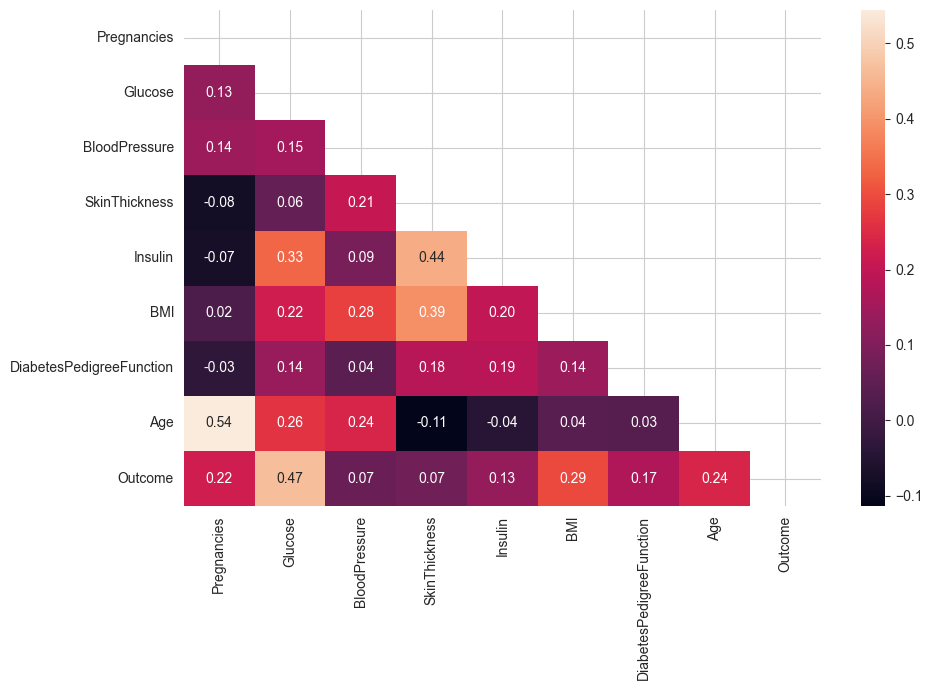

In [117]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

In [118]:
corr_outcome

Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

### Observaciones:

Parece que todas las variables estan relacionadas de alguna u otra forma, procedemos a su estudio

### Correlaciones con la variable objetivo:

### Análisis de variables multivariante: númerico-númerico

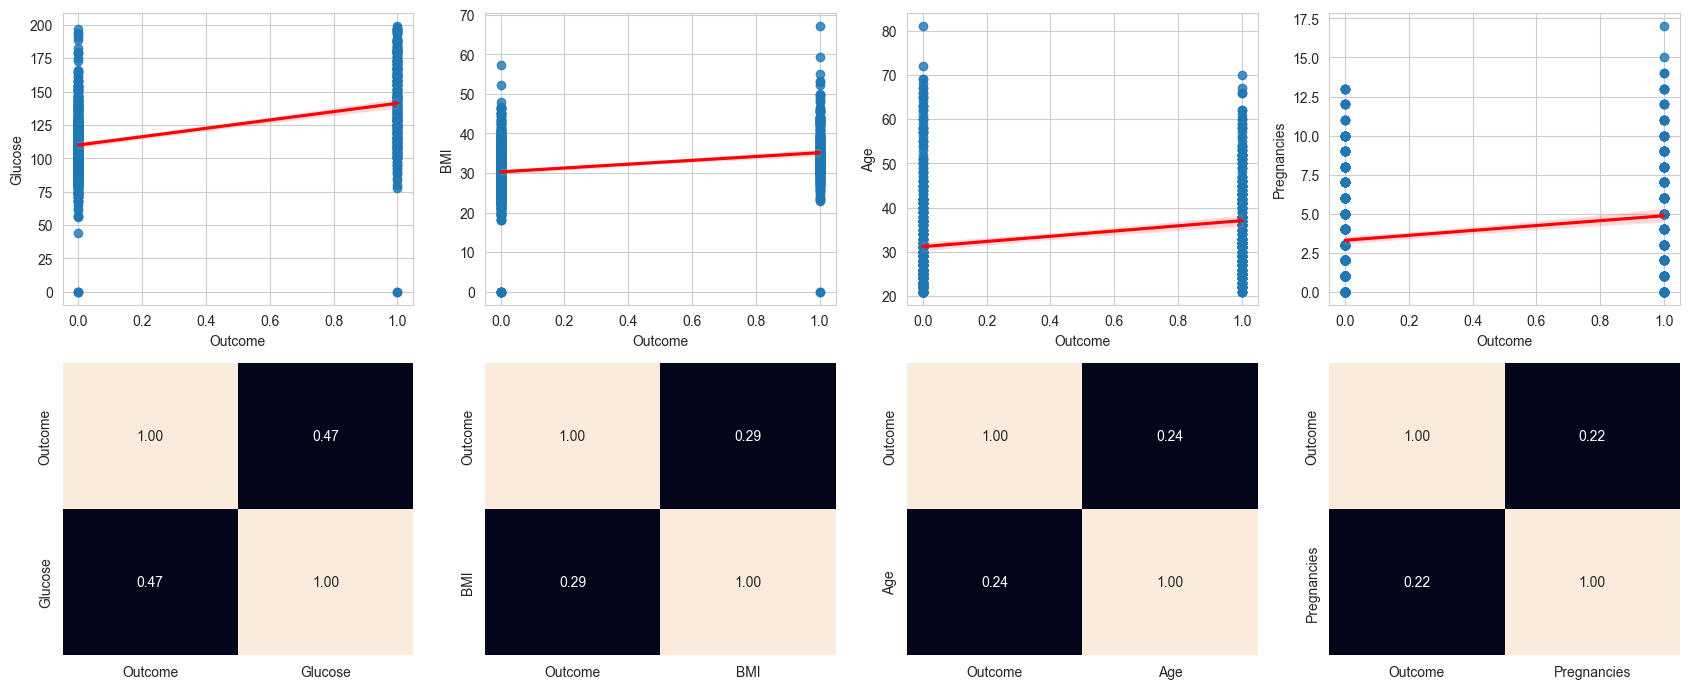

In [119]:
corr_out_glucose = df[["Outcome", "Glucose"]].corr()
corr_out_bmi = df[["Outcome", "BMI"]].corr()
corr_out_age = df[["Outcome", "Age"]].corr()
corr_out_pregnant = df[["Outcome", "Pregnancies"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(17, 7))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="Outcome", y="Glucose", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_out_glucose, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="Outcome", y="BMI", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_out_bmi, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="Outcome", y="Age", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_out_age, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="Outcome", y="Pregnancies", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_out_pregnant, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

### Observaciones:

> - Podemos decir que hay linealidad entre las variables más relacionadas con 'Outcome'


### Otras correlaciones interesantes entre variables:

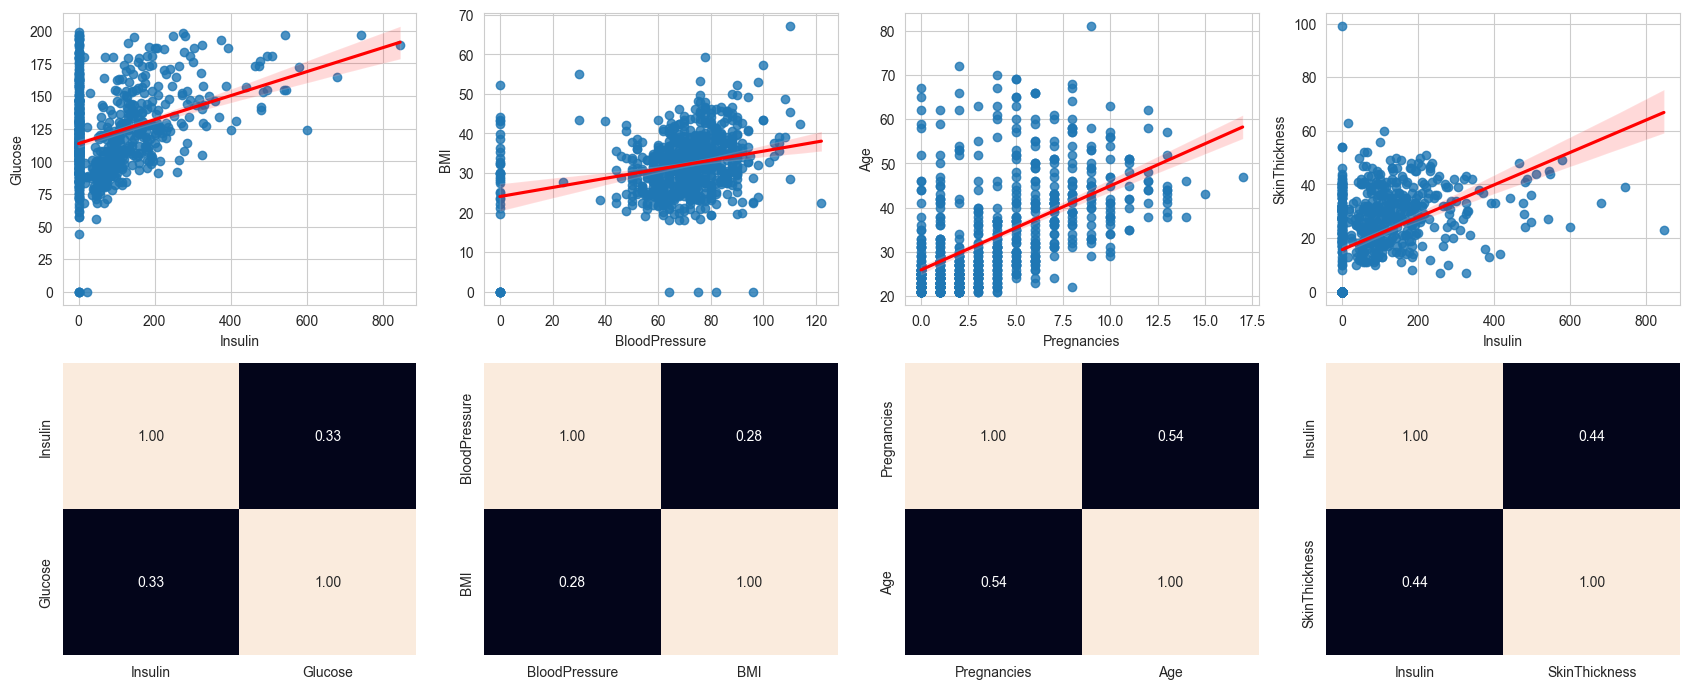

In [120]:
corr_insulin_glucose = df[["Insulin", "Glucose"]].corr()
corr_blood_bmi = df[["BloodPressure", "BMI"]].corr()
corr_pregnant_age = df[["Pregnancies", "Age"]].corr()
corr_insulin_skin = df[["Insulin", "SkinThickness"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(17, 7))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="Insulin", y="Glucose", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_insulin_glucose, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="BloodPressure", y="BMI", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_blood_bmi, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="Pregnancies", y="Age", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_pregnant_age, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="Insulin", y="SkinThickness", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_insulin_skin, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

## Ingeniería de características

### Observaciones:

> - Podemos decir que hay linealidad entre las variables más relacionadas con 'Outcome'


### Análisis de outliers

#### Análisis descriptivo

In [121]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


#### Visualización

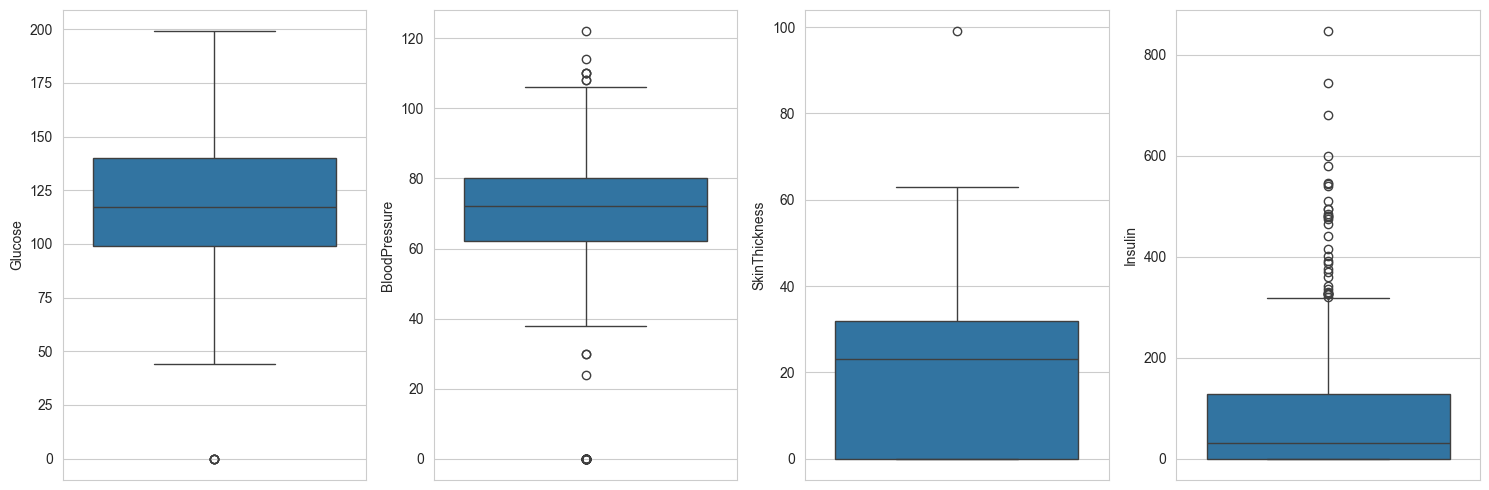

In [122]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="Glucose")
sns.boxplot(ax=axis[1], data=df, y="BloodPressure")
sns.boxplot(ax=axis[2], data=df, y="SkinThickness")
sns.boxplot(ax=axis[3], data=df, y="Insulin")
plt.tight_layout()
plt.show()

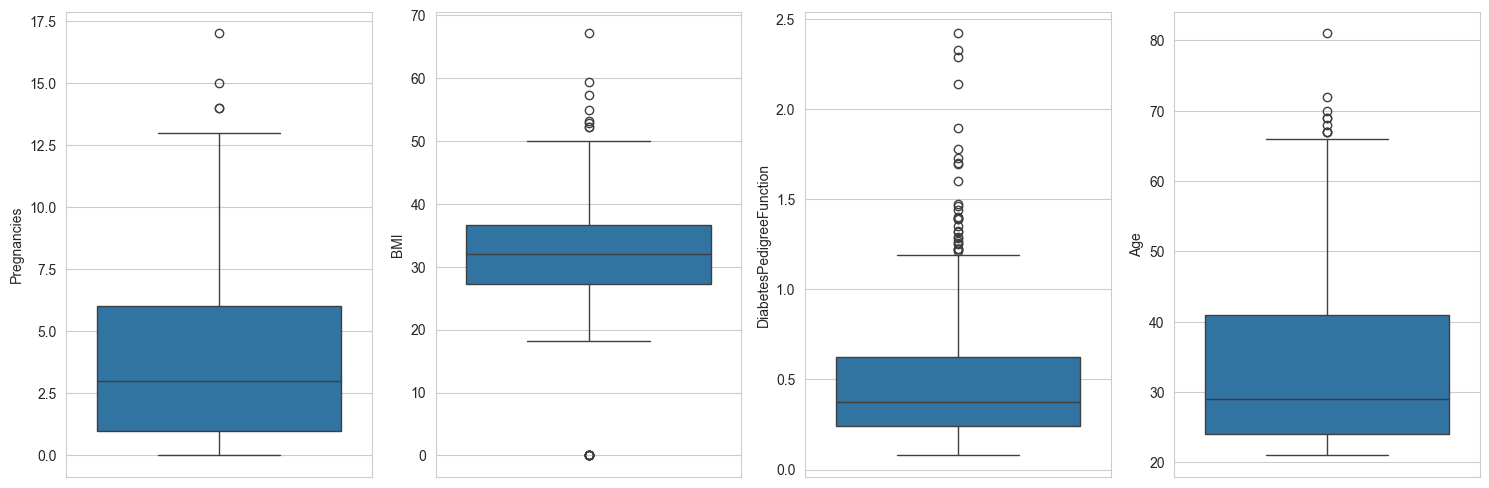

In [123]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="Pregnancies")
sns.boxplot(ax=axis[1], data=df, y="BMI")
sns.boxplot(ax=axis[2], data=df, y="DiabetesPedigreeFunction")
sns.boxplot(ax=axis[3], data=df, y="Age")
plt.tight_layout()
plt.show()

### Observaciones:

> - Observamos posibles valores "raros" en diferentes variables, posible sustitución: eliminar datos, sustituir por la moda, sustituir por K-Nearest Neighbors


#### Valores atípicos 'Glucose'

In [124]:
df['Glucose'].describe()

count    768.000000
mean     120.894531
std       31.972618
min        0.000000
25%       99.000000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [125]:

q1_gloucose = df["Glucose"].quantile(0.25)
q3_gloucose = df["Glucose"].quantile(0.75)
iqr_gloucose = q3_gloucose - q1_gloucose

# Definir los límites inferior y superior
lower_limit_gloucose = 0 if (q1_gloucose - 1.5 * iqr_gloucose) < 0 else q1_gloucose - 1.5 * iqr_gloucose
upper_limit_gloucose = q3_gloucose + 1.5 * iqr_gloucose

f"Límite superior: {round(upper_limit_gloucose, 2)}, Límite inferior: {round(lower_limit_gloucose, 2)}, Rango intercuartílico: {round(iqr_gloucose, 2)}"

'Límite superior: 202.12, Límite inferior: 37.12, Rango intercuartílico: 41.25'

In [126]:
df.loc[df['Glucose'] <= 37]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


#### Observamos valores que no tienen sentido 'glucosa = 0', consideramos eliminarlos o sustituirlos

#### Valores atípicos 'Blood pressure'

In [127]:
df['BloodPressure'].describe()

count    768.000000
mean      69.105469
std       19.355807
min        0.000000
25%       62.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [128]:
q1_blood = df['BloodPressure'].quantile(0.25)
q3_blood = df['BloodPressure'].quantile(0.75)
iqr_blood = q3_blood - q1_blood

# Definir los límites inferior y superior
lower_limit_blood = 0 if (q1_blood - 1.5 * iqr_blood) < 0 else q1_blood - 1.5 * iqr_blood
upper_limit_blood = q3_blood + 1.5 * iqr_blood

f"Límite superior: {round(upper_limit_blood, 2)}, Límite inferior: {round(lower_limit_blood, 2)}, Rango intercuartílico: {round(iqr_blood, 2)}"

'Límite superior: 107.0, Límite inferior: 35.0, Rango intercuartílico: 18.0'

In [129]:
df.loc[df['BloodPressure']<35]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10,115,0,0,0,35.3,0.134,29,0
15,7,100,0,0,0,30.0,0.484,32,1
18,1,103,30,38,83,43.3,0.183,33,0
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
78,0,131,0,0,0,43.2,0.270,26,1
81,2,74,0,0,0,0.0,0.102,22,0
125,1,88,30,42,99,55.0,0.496,26,1
172,2,87,0,23,0,28.9,0.773,25,0
193,11,135,0,0,0,52.3,0.578,40,1


#### Observamos lo mismo que con la variable 'glucose', existen valores sin sentido para esta variable

#### Valores atípicos 'Insulin'

In [130]:
df['Insulin'].describe().T

count    768.000000
mean      79.799479
std      115.244002
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [131]:
q1_insulin = df['Insulin'].quantile(0.25)
q3_insulin = df['Insulin'].quantile(0.75)
iqr_insulin = q3_insulin - q1_insulin

# Definir los límites inferior y superior
lower_limit_insulin = 0 if (q1_insulin - 1.5 * iqr_insulin) < 0 else q1_insulin - 1.5 * iqr_insulin
upper_limit_insulin = q3_insulin + 1.5 * iqr_insulin

f"Límite superior: {round(upper_limit_insulin, 2)}, Límite inferior: {round(lower_limit_insulin, 2)}, Rango intercuartílico: {round(iqr_insulin, 2)}"

'Límite superior: 318.12, Límite inferior: 0, Rango intercuartílico: 127.25'

In [132]:
df.loc[df['Insulin']<=0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
764,2,122,70,27,0,36.8,0.340,27,0
766,1,126,60,0,0,30.1,0.349,47,1


#### No es coherente el valor minimo con la realidad, debemos decidir si mantener estos valores o eliminarlos/sustituirlos

### Análisis de valores faltantes

In [133]:
df.isnull().sum().sort_values(ascending=False) / len(df)

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

#### En este caso no existen valores nulos pero sí valores incoherentes, que pueden ser errores de medición o de recopilación.

Tres posibles enfoques: eliminar datos, sustituir por la moda, sustituir por K-Nearest Neighbors

### Eliminar valores incoherentes:

In [134]:
df_filtrado = df.query("Glucose != 0 and BloodPressure != 0 and Insulin != 0 and SkinThickness != 0")
df_filtrado

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
753,0,181,88,44,510,43.3,0.222,26,1
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


#### Posible mal función del modelo al truncar los datos

### Sustitucion por la moda:

In [135]:
df_mode = df.copy()
df_mode.loc[df_mode['Insulin'] <= 0, 'Insulin'] = np.nan
df_mode.loc[df_mode['SkinThickness'] <= 0, 'SkinThickness'] = np.nan
df_mode

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,NaN,33.6,0.627,50,1
1,1,85,66,29.0,NaN,26.6,0.351,31,0
2,8,183,64,NaN,NaN,23.3,0.672,32,1
3,1,89,66,23.0,94.0,28.1,0.167,21,0
4,0,137,40,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.0,180.0,32.9,0.171,63,0
764,2,122,70,27.0,NaN,36.8,0.340,27,0
765,5,121,72,23.0,112.0,26.2,0.245,30,0
766,1,126,60,NaN,NaN,30.1,0.349,47,1


In [136]:
df_mode.isnull().sum().sort_values(ascending=False) / len(df)

Insulin                     0.486979
SkinThickness               0.295573
Pregnancies                 0.000000
BloodPressure               0.000000
Glucose                     0.000000
BMI                         0.000000
DiabetesPedigreeFunction    0.000000
Age                         0.000000
Outcome                     0.000000
dtype: float64

In [137]:
df_mode["Insulin"] = df_mode["Insulin"].fillna(df_mode["Insulin"].mode()[0])
df_mode["SkinThickness"] = df_mode["SkinThickness"].fillna(df_mode["SkinThickness"].mode()[0])

In [138]:
df_mode.isnull().sum().sort_values(ascending=False) / len(df)

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

### Sustitución por K-Nearest Neighbors

In [139]:
df_kn = df.copy()
df_kn.loc[df_kn['Insulin'] <= 0, 'Insulin'] = np.nan
df_kn.loc[df_kn['SkinThickness'] <= 0, 'SkinThickness'] = np.nan


In [140]:
imputer = KNNImputer(n_neighbors=5)
df_kn[['Insulin', 'SkinThickness']] = imputer.fit_transform(df_kn[['Insulin', 'SkinThickness']])
df_kn

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.00000,232.600000,33.6,0.627,50,1
1,1,85,66,29.00000,184.800000,26.6,0.351,31,0
2,8,183,64,29.15342,155.548223,23.3,0.672,32,1
3,1,89,66,23.00000,94.000000,28.1,0.167,21,0
4,0,137,40,35.00000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.00000,180.000000,32.9,0.171,63,0
764,2,122,70,27.00000,155.400000,36.8,0.340,27,0
765,5,121,72,23.00000,112.000000,26.2,0.245,30,0
766,1,126,60,29.15342,155.548223,30.1,0.349,47,1


## Split de datos (elegimos la variable outcome como target)


In [141]:
df_filtrado

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
753,0,181,88,44,510,43.3,0.222,26,1
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


### Dataset con valores eliminados

In [142]:
X_train_filtrado, X_test_filtrado, y_train_filtrado, y_test_filtrado = train_test_split(df_filtrado.drop('Outcome', axis=1), 
                                                                                        df_filtrado['Outcome'],
                                                                                        test_size=0.2,
                                                                                        random_state=24,
                                                                                        stratify=df_filtrado['Outcome'])

df_train_filtrado = pd.concat([X_train_filtrado, y_train_filtrado],axis=1)
df_test_filtrado = pd.concat([X_test_filtrado, y_test_filtrado], axis=1)

df_train_filtrado

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
546,5,187,76,27,207,43.6,1.034,53,1
92,7,81,78,40,48,46.7,0.261,42,0
568,4,154,72,29,126,31.3,0.338,37,0
659,3,80,82,31,70,34.2,1.292,27,1
111,8,155,62,26,495,34.0,0.543,46,1
...,...,...,...,...,...,...,...,...,...
709,2,93,64,32,160,38.0,0.674,23,1
516,9,145,88,34,165,30.3,0.771,53,1
452,0,91,68,32,210,39.9,0.381,25,0
610,3,106,54,21,158,30.9,0.292,24,0


In [143]:
df_train_filtrado.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-train-filtrado.csv", index=False)
df_test_filtrado.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-test-filtrado.csv", index=False)


### Dataset con valores nulos sustituidos por la moda

In [144]:
X_train_mode, X_test_mode, y_train_mode, y_test_mode = train_test_split(df_mode.drop('Outcome', axis=1), 
                                                                        df_mode['Outcome'],
                                                                        test_size=0.2,
                                                                        random_state=24,
                                                                        stratify=df_mode['Outcome'])

df_train_mode = pd.concat([X_train_mode, y_train_mode],axis=1)
df_test_mode = pd.concat([X_test_mode, y_test_mode],axis=1)

In [145]:
df_train_mode.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-train-mode.csv", index=False)
df_test_mode.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-test-mode.csv", index=False)


### Dataset con valores nulos sustituidos por KNN neighbors

In [146]:
X_train_kn, X_test_kn, y_train_kn, y_test_kn = train_test_split(df_kn.drop('Outcome', axis=1), 
                                                                        df_kn['Outcome'],
                                                                        test_size=0.2,
                                                                        random_state=24,
                                                                        stratify=df_kn['Outcome'])

df_train_kn = pd.concat([X_train_kn, y_train_kn], axis=1)
df_test_kn = pd.concat([X_test_kn, y_test_kn], axis=1)

In [147]:
df_train_kn.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-train-kn.csv", index=False)
df_test_kn.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-test-kn.csv", index=False)
